In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from feature_engine.selection import MRMR


X = pd.read_csv("../dataset/j_kampe.csv")
y = pd.read_csv("../dataset/distances.csv")["distance"]

X = X[1000:]
y = y[1000:]

def plot_top_features(importance: pd.Series, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh", color="gray")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# FEATURE SELECTION

## Correlation

--- Method (i): Correlation Ranking ---


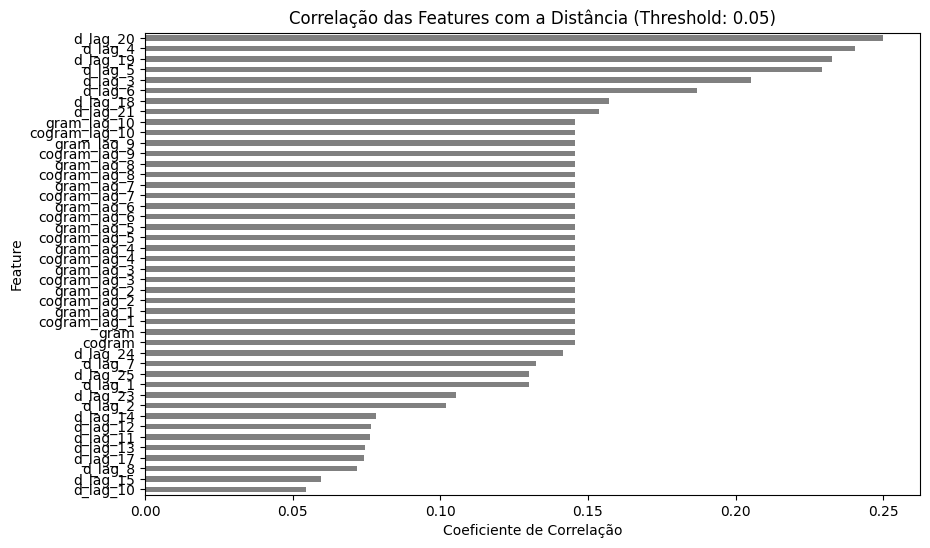

In [ ]:
print("--- Method (i): Correlation Ranking ---")
correlations = X.corrwith(y)
threshold = 0.05
sorted_correlation_rank = correlations.abs().sort_values(ascending=False)
top_features = sorted_correlation_rank[sorted_correlation_rank > threshold]

top_features.index.to_series().to_csv("../results/correlation_feature_selection_v2.csv", index=False, header=["feature"])

plot_top_features(
    top_features,
    f"Correlação das Features com a Distância (Threshold: {threshold})",
    "Coeficiente de Correlação",
    "Feature"
)

## Random Forest

--- Method (ii) Random Forest Importance Ranking ---


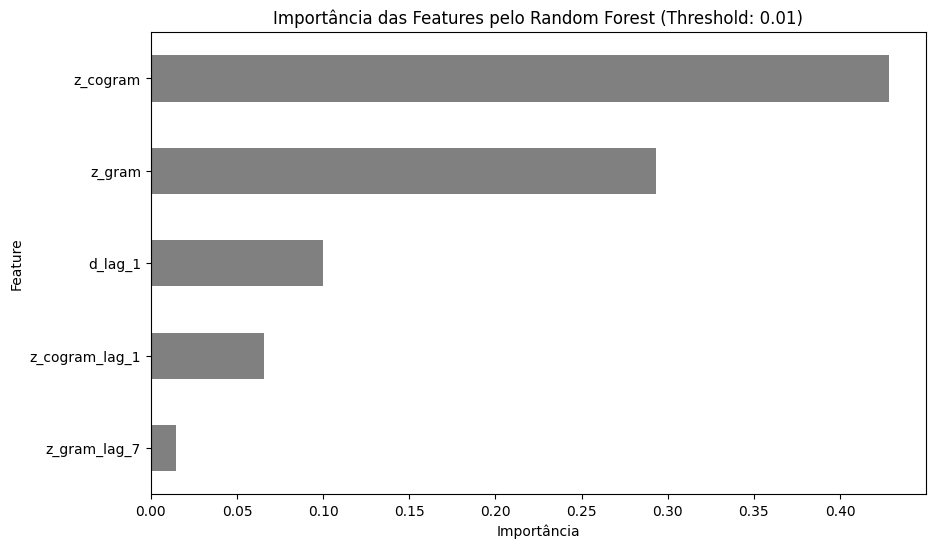

In [ ]:
print("--- Method (ii) Random Forest Importance Ranking ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
sorted_rf_rank = rf_importance.sort_values(ascending=False)
top_rf_features = sorted_rf_rank[sorted_rf_rank > 0.01]

top_rf_features.index.to_series().to_csv("../results/random_forest_feature_selection_v2.csv", index=False, header=["feature"])

plot_top_features(
    top_rf_features,
    "Importância das Features pelo Random Forest (Threshold: 0.01)",
    "Importância",
    "Feature"
)

## Gevrey Method

--- Method (iii) Neural Network Importance Ranking ---


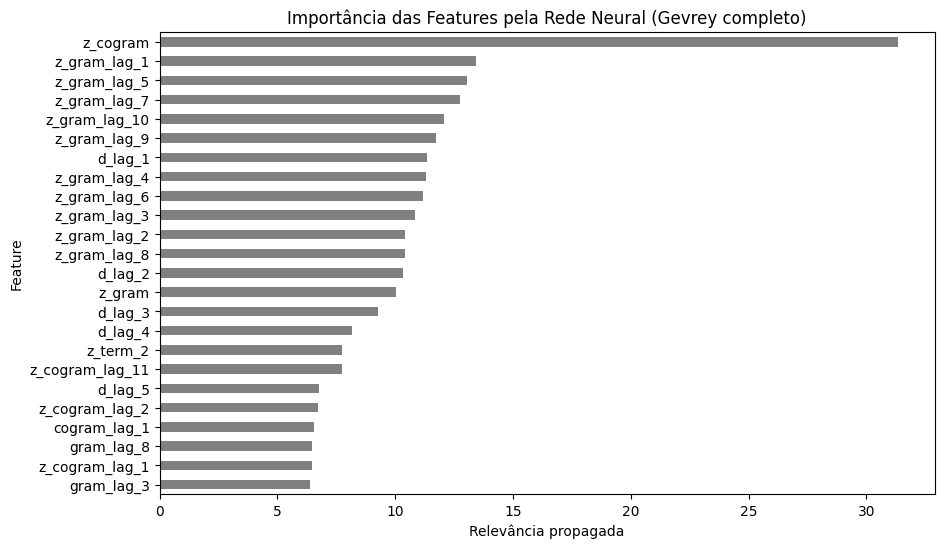

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("--- Method (iii) Neural Network Importance Ranking ---")
nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y)
weights = nn_model.coefs_
feature_relevance = np.abs(weights[0])

for i in range(1, len(weights)):
    feature_relevance = feature_relevance @ np.abs(weights[i])

feature_importance = feature_relevance.sum(axis=1)
nn_importance = pd.Series(feature_importance, index=X.columns)

threshold_nn = np.percentile(feature_importance, 75)

final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

final_ranked_features.index\
    .to_series()\
    .to_csv("../results/gevrey_method_feature_selection_v2.csv", index=False, header=["feature"])

plot_top_features(
    final_ranked_features,
    "Importância das Features pela Rede Neural (Gevrey completo)",
    "Relevância propagada",
    "Feature"
)

## mRMR

In [ ]:
feature_numbers = [10, 14, 20]

for feature_number in feature_numbers:
    n_features_mrmr = 10
    mrmr_selector = MRMR(method="MID", regression=True, max_features=feature_number)
    X_mrmr = mrmr_selector.fit_transform(X, y)
    selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
    pd.DataFrame({"feature": selected_features}).to_csv(f"../results/mrmr_{feature_number}_features_v2.csv", index=False)